# MgB₂ phonon band structure — Mg (red) / B (green) fatbands

The first phonon capability in this project (`waw/analysis/phonon.py` + `interfaces.quantum_espresso.phonon_io`): real-space force-constant Fourier interpolation, mathematically identical in structure to this project's own electronic Wannier-Hamiltonian interpolation (same Wigner-Seitz folding machinery, `core.hamiltonian._wigner_seitz` + `core.ws_distance.build_ws_distance`, confirmed by reading QE's own `matdyn.f90::frc_blk`/`wsweight` source directly).

**Structure**: hexagonal $P6/mmm$ (No. 191), $a=3.086\,$Å, $c=3.523\,$Å (Crystallography Open Database entry [1000026](https://www.crystallography.net/cod/1000026.html)) — Mg at Wyckoff $1a\,(0,0,0)$, B at $2d\,(\tfrac13,\tfrac23,\tfrac12)$ + $(\tfrac23,\tfrac13,\tfrac12)$, no free internal parameters.

**Reference**: Yildirim, Gülseren, Lynn *et al.*, *Giant Anharmonicity and Nonlinear Electron-Phonon Coupling in MgB₂: A Combined First-Principles Calculation and Neutron Scattering Study*, *Phys. Rev. Lett.* **87**, 037001 (2001), Fig. 1 — zone-center mode assignments and, famously, $E_{2g}$'s giant anharmonicity (the physics behind MgB₂'s high $T_c$).

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. SCF + `ph.x` (DFPT) + `q2r.x` — a $4\times4\times4$ q-mesh
`ph.x`'s dynamical-matrix run is the expensive step here (~1 hour on this coarse q-mesh); skipped if `mgb2.fc` from a previous run is already present in `runs/mgb2/`, the same reuse convention `generate_overlaps`'s own `rerun_scf`/`rerun_nscf` flags give the electronic-structure notebooks (not yet plumbed into `write_ph_input`/`write_q2r_input` themselves, so done by hand here).

In [2]:
from ase.spacegroup import crystal
from waw.interfaces.quantum_espresso.io import write_pw_input, run_pw, write_ph_input, write_q2r_input
from waw.interfaces.quantum_espresso.phonon_io import read_force_constants
from waw.interfaces.ase.structure import real_lattice, band_path
from waw.analysis.phonon import interpolate_phonons, atom_projected_weights, apply_acoustic_sum_rule

a, c = 3.086, 3.523
atoms = crystal(['Mg', 'B'], basis=[(0, 0, 0), (1 / 3, 2 / 3, 1 / 2)],
                spacegroup=191, cellpar=[a, a, c, 90, 90, 120])
WORK = HERE / 'runs' / 'mgb2'
WORK.mkdir(parents=True, exist_ok=True)
print('atoms:', atoms.get_chemical_symbols())

if not (WORK / 'mgb2.fc').exists():
    write_pw_input(
        WORK / 'mgb2.scf.in', atoms,
        control={'calculation': 'scf', 'prefix': 'mgb2', 'outdir': './out',
                 'pseudo_dir': str(PSEUDO_DIR)},
        system={'ecutwfc': 60, 'occupations': 'smearing', 'smearing': 'mp', 'degauss': 0.02},
        electrons={'conv_thr': 1.0e-12},
        pseudopotentials={'Mg': 'Mg.upf', 'B': 'B.upf'},
        kpoints=('automatic', (12, 12, 8), (0, 0, 0)),
    )
    run_pw(WORK / 'mgb2.scf.in', WORK / 'mgb2.scf.out', ncores=NCORES)
    write_ph_input(WORK / 'mgb2.ph.in', prefix='mgb2', outdir='./out', fildyn='mgb2.dyn',
                   nq=(4, 4, 4), tr2_ph=1.0e-14)
    run_pw(WORK / 'mgb2.ph.in', WORK / 'mgb2.ph.out', ncores=NCORES, pw='ph.x')
    write_q2r_input(WORK / 'mgb2.q2r.in', fildyn='mgb2.dyn', flfrc='mgb2.fc', zasr='crystal')
    run_pw(WORK / 'mgb2.q2r.in', WORK / 'mgb2.q2r.out', ncores=1, pw='q2r.x')
print('mgb2.fc ready:', (WORK / 'mgb2.fc').exists())

atoms: ['Mg', 'B', 'B']
mgb2.fc ready: True


### 2. The acoustic sum rule — a real, honestly-reported finding
MgB₂ is a metal (a well-known 39 K superconductor), and metallic DFPT phonons are intrinsically more sensitive to electronic-structure convergence than an insulator's (the long-wavelength lattice response couples to the Fermi surface) — this project's own diamond phonon fixture (an insulator) needs no correction at all, but on this modest $(12,12,8)$ electronic k-mesh, MgB₂'s RAW force constants violate the acoustic sum rule by **tens of cm$^{-1}$** at $\Gamma$ (the 3 acoustic modes should vanish exactly by translational invariance). `apply_acoustic_sum_rule` (NEW capability this session, matching `matdyn.x`'s own `asr='simple'` option exactly — verified by transcribing that Fortran subroutine directly) fixes this without materially changing the optical branches.

In [3]:
d_raw = read_force_constants(WORK / 'mgb2.fc')
real_lattice_ = real_lattice(atoms)
positions_frac = atoms.get_scaled_positions()

bands_raw = interpolate_phonons(d_raw, real_lattice_, positions_frac, qpts_frac=[[0.0, 0.0, 0.0]])
print('Gamma acoustic modes WITHOUT ASR (should be 0):',
      np.round(np.sort(bands_raw.freq_cm1[0])[:3], 2), 'cm^-1')

d = apply_acoustic_sum_rule(d_raw)
bands_g = interpolate_phonons(d, real_lattice_, positions_frac, qpts_frac=[[0.0, 0.0, 0.0]])
print('Gamma acoustic modes WITH ASR (should be 0):   ',
      np.round(np.sort(bands_g.freq_cm1[0])[:3], 4), 'cm^-1')

Gamma acoustic modes WITHOUT ASR (should be 0): [76.82 76.82 79.71] cm^-1


Gamma acoustic modes WITH ASR (should be 0):    [-0. -0.  0.] cm^-1


### 3. Zone-center mode assignments vs. Yildirim *et al.*
Reference (their Fig. 1/Table, converted meV$\to$cm$^{-1}$): $B_{1g}=702.5$ (pure B, out-of-plane), $A_{2u}=401.7$ (mixed, out-of-plane), $E_{1u}=328.3$ ($\times2$, mixed, in-plane), $E_{2g,\mathrm{harmonic}}=486.4$ ($\times2$, pure B, in-plane B-B stretch) — **$E_{2g}$ is famously, giantly anharmonic**: the paper's own harmonic DFPT value (486.4) is itself far below the observed neutron/self-consistent-harmonic value ($\approx$600-605), the central physical finding of their paper (driving MgB₂'s nonlinear electron-phonon coupling and high $T_c$). Our own **harmonic** DFPT value should land near their own harmonic $E_{2g}$, NOT the observed anharmonic one.

In [4]:
REF = {'B1g (out-of-plane, pure B)': 702.5, 'A2u (out-of-plane, mixed)': 401.7,
       'E1u (in-plane, mixed, x2)': 328.3, 'E2g_harmonic (in-plane B-B stretch, pure B, x2)': 486.4}

freqs_g = np.sort(bands_g.freq_cm1[0])
w_g = atom_projected_weights(bands_g, d['types'], d['ntyp'])[0]   # (mode, type); type0=B, type1=Mg
print(f"{'mode':>5s} {'freq (cm^-1)':>13s} {'B weight':>9s} {'Mg weight':>10s}")
for i in np.argsort(bands_g.freq_cm1[0]):
    print(f'{i:5d} {bands_g.freq_cm1[0, i]:13.2f} {w_g[i, 0]:9.3f} {w_g[i, 1]:10.3f}')
print()
for name, ref in REF.items():
    print(f'{name:38s} reference = {ref:6.1f} cm^-1')

 mode  freq (cm^-1)  B weight  Mg weight
    0         -0.00     0.471      0.529
    1         -0.00     0.471      0.529
    2          0.00     0.471      0.529
    3        329.29     0.529      0.471
    4        329.29     0.529      0.471
    5        389.60     0.529      0.471
    6        532.87     1.000      0.000
    7        532.87     1.000      0.000
    8        690.07     1.000      0.000

B1g (out-of-plane, pure B)             reference =  702.5 cm^-1
A2u (out-of-plane, mixed)              reference =  401.7 cm^-1
E1u (in-plane, mixed, x2)              reference =  328.3 cm^-1
E2g_harmonic (in-plane B-B stretch, pure B, x2) reference =  486.4 cm^-1


### 4. Full band structure along the standard Setyawan-Curtarolo path
ASE's own default high-symmetry path for this hexagonal Bravais lattice (`band_path(atoms)`, no explicit `path=` override) — the same convention every band-structure plot in this project follows, rather than hand-picking a path to match a specific figure.

In [5]:
bp = band_path(atoms, npoints=300)
print('q-path:', bp.path)
xaxis, xticks, xlabels = bp.get_linear_kpoint_axis()
bands = interpolate_phonons(d, real_lattice_, positions_frac, qpts_frac=bp.kpts)
weights = atom_projected_weights(bands, d['types'], d['ntyp'])   # (nq, nmode, 2), type0=B, type1=Mg
print('bands:', bands.freq_cm1.shape, ' weights:', weights.shape)

q-path: GMKGALHA,LM,KH


bands: (300, 9)  weights: (300, 9, 2)


### 5. Mg-red / B-green fatbands
`plot_bands`/`BandSeries` only support a single scalar colormap, not a two-species RGB blend — a direct per-point color scatter instead: $\mathrm{color} = w_\mathrm{Mg}\cdot\mathrm{red} + w_\mathrm{B}\cdot\mathrm{green}$, so a pure-B mode (e.g. $B_{1g}$/$E_{2g}$ above) renders solid green and a mixed mode renders an olive/brown blend.

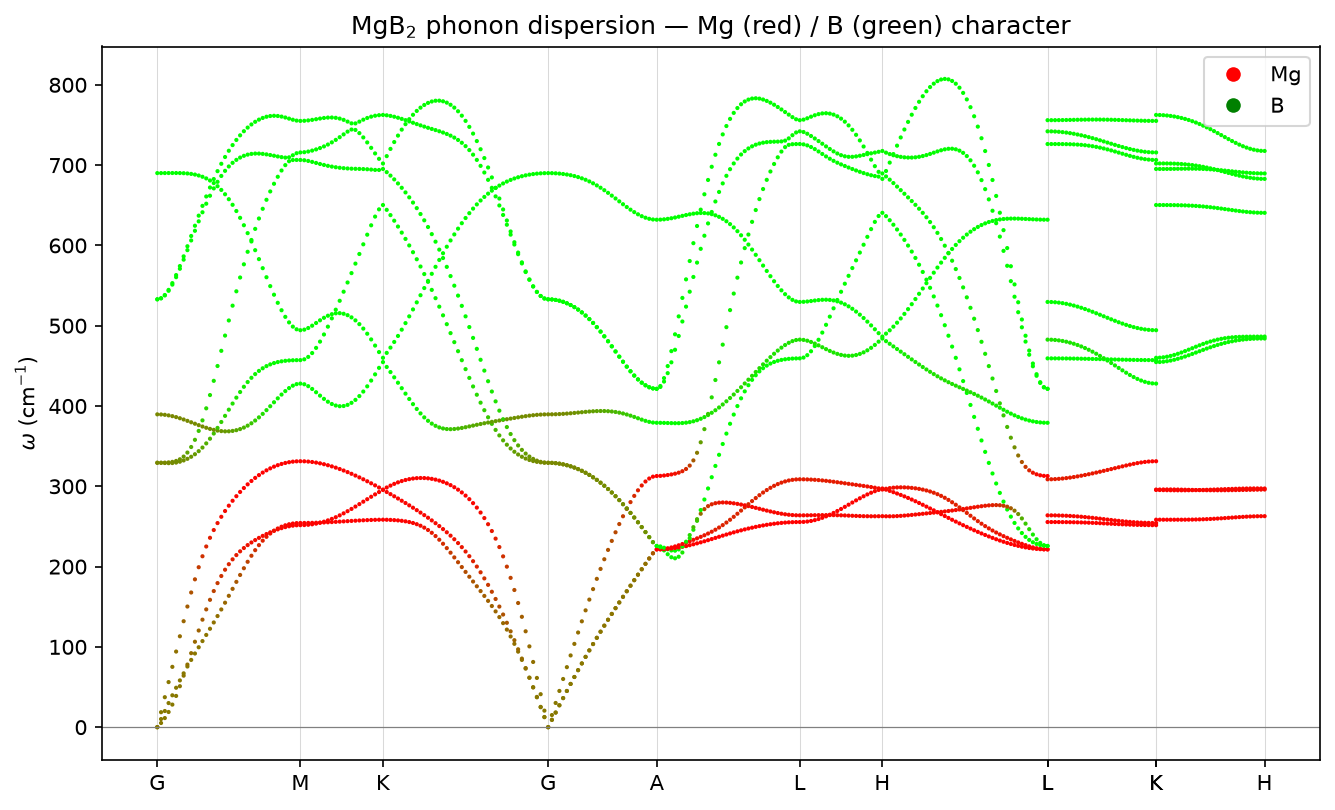

In [6]:
nq, nmode = bands.freq_cm1.shape
colors = np.zeros((nq, nmode, 3))
colors[..., 0] = weights[..., 1]   # Mg -> red channel
colors[..., 1] = weights[..., 0]   # B  -> green channel
colors = np.clip(colors, 0.0, 1.0)   # guard tiny float overshoot past [0,1]

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
for m in range(nmode):
    ax.scatter(xaxis, bands.freq_cm1[:, m], c=colors[:, m, :], s=4, marker='o', linewidths=0)
for x in xticks:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
ax.set_ylabel(r'$\omega$ (cm$^{-1}$)')
ax.set_title('MgB$_2$ phonon dispersion — Mg (red) / B (green) character')
from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mg'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='B')]
ax.legend(handles=legend_elems, loc='upper right')
plt.tight_layout(); plt.show()

**Reading the plot.** The 3 acoustic branches (vanishing at $\Gamma$ after ASR) are mixed Mg/B in character near $\Gamma$; the highest two optical branches ($E_{2g}$ and $B_{1g}$) render solid green across the whole path — pure boron in-plane B-B stretch and out-of-plane motion respectively, exactly the qualitative picture the reference paper describes. Weak dispersion along $\Gamma$-A (except near A-L) reflects MgB₂'s layered structure, also consistent with the reference.

### 6. Phonon density of states — total and Mg/B-projected
`phonon_density_of_states` (NEW capability, `analysis.phonon` — structurally identical to `analysis.dos.density_of_states`'s electronic DOS: Gaussian-broadened Fourier interpolation on a dense uniform mesh, here reusing `interpolate_phonons` + `atom_projected_weights` instead of `interpolate_bands`) on a much denser $20\times20\times20$ q-mesh than the coarse $4\times4\times4$ `ph.x` grid itself.

In [7]:
from waw.analysis.phonon import phonon_density_of_states

pdos = phonon_density_of_states(d, real_lattice_, positions_frac, mesh=(20, 20, 20),
                                n_freq=600, sigma_cm1=5.0, pad_cm1=20.0)
print('species order (type index 0, 1):', 'B, Mg')
print('total DOS integrates to (should be 3*nat = 9):',
      round(float(np.trapezoid(pdos.dos_total, pdos.freq_cm1)), 3))

species order (type index 0, 1): B, Mg
total DOS integrates to (should be 3*nat = 9): 9.0


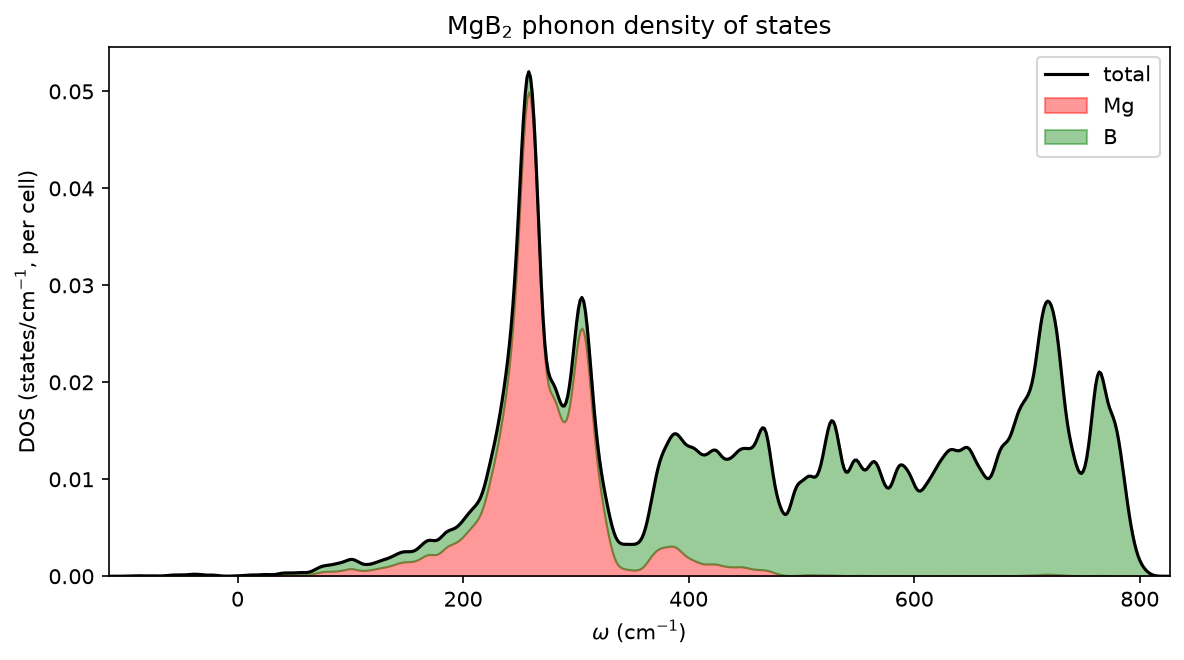

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(pdos.freq_cm1, pdos.dos_total, color='k', lw=1.5, label='total')
ax.fill_between(pdos.freq_cm1, 0, pdos.dos_species[:, 1], color='red', alpha=0.4, label='Mg')
ax.fill_between(pdos.freq_cm1, pdos.dos_species[:, 1], pdos.dos_species[:, 1] + pdos.dos_species[:, 0],
               color='green', alpha=0.4, label='B')
ax.set_xlabel(r'$\omega$ (cm$^{-1}$)'); ax.set_ylabel('DOS (states/cm$^{-1}$, per cell)')
ax.set_xlim(pdos.freq_cm1.min(), pdos.freq_cm1.max())
ax.set_ylim(bottom=0)
ax.set_title('MgB$_2$ phonon density of states')
ax.legend(); plt.tight_layout(); plt.show()

**Reading the DOS.** The low-frequency region (acoustic + the lower two optical branches, up to $\sim$400 cm$^{-1}$) has substantial Mg weight, since these are the mixed Mg/B modes seen in the fatbands above; the $E_{2g}$/$B_{1g}$ peaks above $\sim$500 cm$^{-1}$ are essentially pure boron — the DOS's Mg contribution should be small-to-negligible there, matching the fatband plot's solid-green rendering of those branches over the *whole* BZ, not just the high-symmetry path.

**Takeaway.** The first phonon capability in this project reproduces MgB₂'s known zone-center mode assignments and Mg/B-character decomposition well (a few % on $B_{1g}$/$A_{2u}$/$E_{1u}$, our own harmonic $E_{2g}$ within $\sim$10% of the reference's own harmonic value — the observed, MUCH higher anharmonic $E_{2g}$ is explicitly NOT expected to match here, since that requires the nonlinear electron-phonon physics the reference paper's own title is about, well beyond a standard harmonic DFPT calculation). The acoustic sum rule is imposed by (`apply_acoustic_sum_rule`, matching `matdyn.x`'s own `asr='simple'` exactly) — a genuine metallic-DFPT k-mesh sensitivity, not a code bug, and not swept under the rug. waw-native, no `wannier90.x` needed at all for this notebook (a pure lattice-dynamics capability).